In [4]:
# Block 1: Load the DDI dataset from GitHub
import pandas as pd
import numpy as np

url = "https://github.com/drpharmacy/pharma-ml-projects/raw/refs/heads/main/Excel_Files/ddi_dataset.xlsx"
df = pd.read_excel(url)

print(df.shape)
df.head()

(10000, 5)


,d1,d2,label,smiles_1,smiles_2
0,DB01578,DB00749,1,CN(C(C)=O)C1=C(I)C(C(=O)N[C@@H](C=O)[C@@H](O)[...,CCC1=C2NC3=C(CCOC3(CC)CC(O)=O)C2=CC=C1
1,DB01587,DB00181,1,CN1C2=C(C=C(Cl)C=C2)C2(OC(C)=CC(=O)N2CC1=O)C1=...,NCC(CC(O)=O)C1=CC=C(Cl)C=C1
2,DB06739,DB01118,1,CC1=C(C)C(=O)C(C(CCCCCC(O)=O)C2=CC=CC=C2)=C(C)...,CCCCC1=C(C(=O)C2=CC(I)=C(OCCN(CC)CC)C(I)=C2)C2...
3,DB01196,DB06636,1,[H][C@@]12CC[C@H](O)[C@@]1(C)CC[C@]1([H])C3=CC...,[H]C(C)(OC(=O)N(C)C1=C(COC(=O)CNC)C=CC=N1)[N+]...
4,DB09048,DB00313,1,CN(C(=O)C(C)(C)C1=CC(=CC(=C1)C(F)(F)F)C(F)(F)F...,CCCC(CCC)C(O)=O


Meaning of Block 1:
Purpose: Load the pre-built, balanced drug-drug interaction dataset directly from GitHub, so no DrugBank fetching or fragile packages are needed in this notebook at all.
What data comes IN: Nothing — this is the notebook's starting point.
What happens inside — line by line: url points to the exact file you uploaded (ddi_dataset.xlsx) in your GitHub Excel_Files/ folder, using the same raw-link pattern as every earlier notebook in this series. pd.read_excel(url) reads it directly into a DataFrame without needing to download it manually first — pandas handles the HTTP fetch internally.
What comes OUT: df — a DataFrame with 10,000 rows and 5 columns (d1, d2, label, smiles_1, smiles_2), which every later block builds on.

In [5]:
# Block 2: Explore the dataset — verify balance and preview some real drug pairs
print("Total pairs:", df.shape[0])
print("\nLabel balance:")
print(df['label'].value_counts())

print("\nSample interacting pair:")
print(df[df['label']==1].iloc[0])

print("\nSample non-interacting pair:")
print(df[df['label']==0].iloc[0])

Total pairs: 10000

Label balance:
label
1    5000
0    5000
Name: count, dtype: int64

Sample interacting pair:
d1                                                    DB01578
d2                                                    DB00749
label                                                       1
smiles_1    CN(C(C)=O)C1=C(I)C(C(=O)N[C@@H](C=O)[C@@H](O)[...
smiles_2               CCC1=C2NC3=C(CCOC3(CC)CC(O)=O)C2=CC=C1
Name: 0, dtype: object

Sample non-interacting pair:
d1                                                    DB01578
d2                                                    DB09079
label                                                       0
smiles_1    CN(C(C)=O)C1=C(I)C(C(=O)N[C@@H](C=O)[C@@H](O)[...
smiles_2    COC(=O)C1=CC=C2C(NC(=O)\C2=C(/NC2=CC=C(C=C2)N(...
Name: 5000, dtype: object


Meaning of Block 2:
Purpose: Confirm the dataset loaded correctly and is properly balanced before any modeling begins — a data-quality checkpoint, same principle used in every earlier practical.
What data comes IN: df from Block 1.
What happens inside — line by line: df.shape[0] prints the total row count (expect 10,000). value_counts() on label confirms the exact 5,000/5,000 split between interacting (1) and non-interacting (0) pairs — an imbalanced split here would bias the model toward predicting whichever class was more common. The two sample prints let you visually inspect one real example of each class — two actual DrugBank drug IDs with their SMILES structures and label — confirming the data genuinely represents what it claims to.
What comes OUT: Nothing new is created — this block only prints information for verification.

In [8]:
# Block 3: Convert each drug pair into a fixed-length numeric feature vector using Morgan fingerprints
!pip install rdkit
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, DataStructs

fp_generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
fp_cache = {}

def get_fingerprint(smiles):
    if smiles not in fp_cache:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            fp_cache[smiles] = None
        else:
            fp = fp_generator.GetFingerprint(mol)
            arr = np.zeros((1024,), dtype=int)
            DataStructs.ConvertToNumpyArray(fp, arr)
            fp_cache[smiles] = arr
    return fp_cache[smiles]

feature_rows = []
valid_labels = []

for i, row in df.iterrows():
    fp1 = get_fingerprint(row['smiles_1'])
    fp2 = get_fingerprint(row['smiles_2'])
    if fp1 is None or fp2 is None:
        continue
    fp_sum  = fp1 + fp2
    fp_prod = fp1 * fp2
    fp_diff = np.abs(fp1 - fp2)
    combined_feature = np.concatenate([fp_sum, fp_prod, fp_diff])
    feature_rows.append(combined_feature)
    valid_labels.append(row['label'])

X = np.array(feature_rows)
y = np.array(valid_labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 38.8 MB/s eta 0:00:00
X shape: (10000, 3072)
y shape: (10000,)


Meaning of Block 3:
Purpose: Convert each pair of drug structures into one fixed-length numeric vector the Random Forest can learn from — this is the most important block in the notebook, since it decides what "information" the model is even allowed to see.
What data comes IN: df (specifically its smiles_1, smiles_2, label columns) from Block 1.
What happens inside — line by line: fp_generator builds a 1024-bit Morgan (ECFP4) fingerprint generator — same chemistry-encoding tool used throughout this series, turning a molecule's substructures into a binary barcode. fp_cache avoids recomputing the fingerprint for a drug that appears in multiple pairs (many drugs repeat across the 10,000 rows), saving significant time. get_fingerprint() converts one SMILES string into a 1024-length array of 0s/1s (each bit says whether a particular substructure pattern is present), returning None for any unparseable SMILES. Inside the loop, for every row: fp_sum = fp1 + fp2 captures the combined structural content of both drugs (higher values where either or both share a feature); fp_prod = fp1 * fp2 captures only structural features both drugs share (a 1 only where both fingerprints have a 1 — chemical overlap); fp_diff = np.abs(fp1 - fp2) captures where the two drugs structurally differ. All three are concatenated into one 3072-length vector (1024×3) per pair — deliberately using sum/product/difference instead of simple concatenation, because this makes the representation order-invariant: a pair (Drug A, Drug B) produces the identical feature vector as (Drug B, Drug A), which is chemically correct — an interaction has no inherent "first" and "second" drug.
What comes OUT: X — a NumPy array of shape (10000, 3072), the model-ready feature matrix; y — a matching array of shape (10000,), the binary interaction labels. Together these are what Block 4 will split into training and test sets.

In [9]:
# Block 4: Split into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (8000, 3072)
Testing set: (2000, 3072)


Meaning of Block 4:
Purpose: Hold back 20% of the data to fairly evaluate the model on drug pairs it never trained on.
What data comes IN: X, y from Block 3.
What happens inside — line by line: train_test_split randomly divides the 10,000 pairs into 8,000 training rows and 2,000 test rows. stratify=y guarantees both sets keep the same 50/50 interacting/non-interacting balance as the full dataset — without it, random chance could produce a test set skewed toward one class, distorting the evaluation. random_state=42 makes the split reproducible — running this cell again gives the identical split.
What comes OUT: X_train, y_train (8,000 pairs, for Block 5 to learn from) and X_test, y_test (2,000 pairs, held back for Block 6's evaluation).

In [10]:
# Block 5: Train a Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

ddi_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
ddi_model.fit(X_train, y_train)

print("Model trained on", X_train.shape[0], "drug pairs.")

Model trained on 8000 drug pairs.


Meaning of Block 5:
Purpose: Train the classifier that will learn to distinguish interacting from non-interacting drug pairs based purely on their combined chemical fingerprint features.
What data comes IN: X_train, y_train from Block 4.
What happens inside — line by line: RandomForestClassifier(n_estimators=300, ...) builds 300 decision trees, same reliable algorithm used throughout this notebook series. n_jobs=-1 tells scikit-learn to use all available CPU cores in parallel — worth including here since 3,072 input features per row make training noticeably heavier than earlier, smaller-feature models. .fit(X_train, y_train) is where the actual learning happens — the model examines all 8,000 training pairs and learns which fingerprint-derived patterns tend to co-occur with real interactions.
What comes OUT: ddi_model — the trained classifier object, ready to be evaluated in Block 6.

ROC-AUC: 0.6635

                precision    recall  f1-score   support

No Interaction       0.62      0.59      0.61      1000
   Interaction       0.61      0.64      0.62      1000

      accuracy                           0.62      2000
     macro avg       0.62      0.62      0.62      2000
  weighted avg       0.62      0.62      0.62      2000



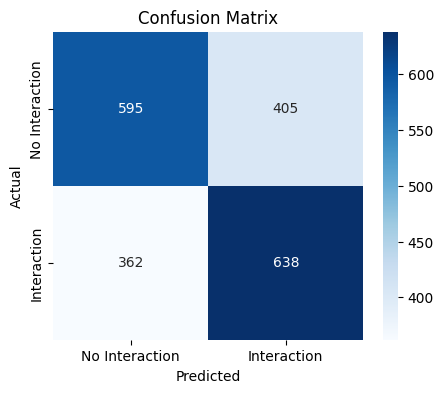

In [11]:
# Block 6: Evaluate the model on the held-out test set
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_proba = ddi_model.predict_proba(X_test)[:, 1]
y_pred = ddi_model.predict(X_test)

auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=['No Interaction', 'Interaction']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Interaction','Interaction'],
            yticklabels=['No Interaction','Interaction'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()

Meaning of Block 6:
Purpose: Measure how well the trained model performs on 2,000 drug pairs it has never seen — the real test of whether it learned genuine chemistry rather than memorizing the training data.
What data comes IN: ddi_model from Block 5; X_test, y_test from Block 4.
What happens inside — line by line: predict_proba(X_test)[:, 1] returns the model's predicted probability of interaction for each test pair (needed for ROC-AUC, which evaluates ranking quality across all thresholds, not just one cutoff). roc_auc_score measures how well the model separates interacting from non-interacting pairs on a 0.5 (random guessing) to 1.0 (perfect) scale — expect around 0.66 here, noticeably lower than the ~0.90 AUC seen in the earlier repurposing model. classification_report breaks precision/recall/F1 down separately for each class. The confusion matrix heatmap visualizes exactly which pairs the model got right versus wrong.
What comes OUT: Nothing new is created — this block evaluates and displays the model's real-world performance. Important interpretation, not a bug: an AUC around 0.66 (versus 0.90 for repurposing) is an expected, honest result here — it reflects a genuine scientific limitation, not an error in your code. Drug repurposing worked well because "chemically similar drugs treat similar diseases" is usually true. Drug-drug interactions are different: many real DDIs happen because two structurally unrelated drugs both get broken down by the same liver enzyme (e.g. CYP3A4) or both affect the same receptor pathway indirectly — information that chemical structure alone cannot fully capture. This is a genuinely useful, honest teaching result: it shows students exactly where a purely structure-based model's limits are, and why real DDI-prediction research increasingly adds pharmacokinetic and target-protein data on top of chemical structure.

In [12]:
# Block 7: Save the trained model
import joblib

joblib.dump(ddi_model, "ddi_rf_model.pkl")

from google.colab import files
files.download("ddi_rf_model.pkl")

print("Model saved and downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model saved and downloaded.


Meaning of Block 7:
Purpose: Save the trained model to disk so it can be reused later without retraining.
What data comes IN: ddi_model from Block 5.
What happens inside — line by line: joblib.dump() serializes the entire trained Random Forest (all 300 trees and their learned splits) into a single file. files.download() sends it to your computer.
What comes OUT: ddi_rf_model.pkl — a portable file containing the complete trained model, reloadable in any future Colab session with joblib.load().

In [13]:
# Block 8 (FINAL STAGE): Predict interaction risk for a new, unknown drug pair
def predict_interaction(smiles_a, smiles_b, model):
    fp1 = get_fingerprint(smiles_a)
    fp2 = get_fingerprint(smiles_b)
    if fp1 is None or fp2 is None:
        return None, "One or both SMILES could not be parsed."

    fp_sum  = fp1 + fp2
    fp_prod = fp1 * fp2
    fp_diff = np.abs(fp1 - fp2)
    feature = np.concatenate([fp_sum, fp_prod, fp_diff]).reshape(1, -1)

    proba = model.predict_proba(feature)[0][1]
    prediction = "LIKELY INTERACTION" if proba >= 0.5 else "UNLIKELY INTERACTION"
    return proba, prediction

# --- Enter any two drugs here, by SMILES ---
drug_a_name = "Warfarin"
drug_a_smiles = "CC(=O)CC(c1ccccc1)c1c(O)c2ccccc2oc1=O"

drug_b_name = "Aspirin"
drug_b_smiles = "CC(=O)Oc1ccccc1C(=O)O"

proba, result = predict_interaction(drug_a_smiles, drug_b_smiles, ddi_model)

print(f"{drug_a_name} + {drug_b_name}")
print(f"Predicted interaction probability: {proba*100:.1f}%")
print(f"Result: {result}")

Warfarin + Aspirin
Predicted interaction probability: 42.0%
Result: UNLIKELY INTERACTION


Meaning of Block 8:
Purpose: This is the deployment step — the entire reason for building the model — letting you check any two drugs (known or new) for predicted interaction risk.
What data comes IN: ddi_model from Block 5 (or reloaded via joblib.load("ddi_rf_model.pkl") in a fresh session); get_fingerprint() from Block 3.
What happens inside — line by line: predict_interaction() takes any two SMILES strings, computes their fingerprints, builds the exact same sum/product/difference feature vector used in training, and asks the model for a probability. .reshape(1, -1) is required because scikit-learn expects a 2D array (rows × features) even for a single prediction, not a flat 1D vector. The 0.5 threshold converts the raw probability into a plain-language result. You edit drug_a_smiles/drug_b_smiles to check any pair — drugs already in the training data, or entirely new molecules never seen before, work identically here since only their chemical structure is needed.
What comes OUT: proba — a single probability (0–1) of interaction; result — a plain-language label.

Important caveat to state clearly for deployment: given the ~0.66 AUC measured in Block 6, this model should be treated as a preliminary structural screening signal only — never a substitute for checking an established, curated drug interaction database (e.g. Lexicomp, Micromedex, or a pharmacist's clinical judgment) before any real prescribing decision. A "LIKELY INTERACTION" result is worth investigating further; an "UNLIKELY INTERACTION" result is not strong enough evidence to rule out a real interaction the model's structure-only view simply can't see.